In [1]:
import sys
sys.path.append('../../')

from samrfi import RFIModels

/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from samrfi import RFIModels, RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/one_antenna_3C129_rflag.ms'
#original_calib = '/home/gpuhost002/ddeal/RFI-AI/original_calib/calib_phase_rflag.ms'

datarfi_3C129 = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_3C129.load(mode='DATA', ant_i=1) # using first two antennas


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:19<00:00, 19.54s/it]


(26, 4, 2048, 511)


In [3]:
datarfi_3C129.rfi_antenna_data = datarfi_3C129.rfi_antenna_data[0:4]

In [4]:
cd /home/gpuhost002/ddeal/RFI-AI/sam2/notebooks

/home/gpuhost002/ddeal/RFI-AI/sam2/notebooks


/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
model_path = "/home/gpuhost002/ddeal/RFI-AI/samrfi_data/models/model_1024_sam2-large_epochs20_20250106_131647.pth"
model = RFIModels(radiorfi_instance=datarfi_3C129, device='cuda',)

model.sam2_ckpt = "../checkpoints/sam2.1_hiera_large.pt"
model.sam2_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

model.device = 'cuda'

model.load_model_sam2(model_path)
model.run_model_sam2(patch_size=1024)

(4, 4, 2048, 511)


/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../../samrfi/rfimodels.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.sam2_predictor.model.load_st

In [6]:

print(model.bbox)
print(model.input_points.shape)
print(model.point_labels.shape)

[   0    0  526 1024]
(999, 2)
(999,)


In [9]:
from skimage.feature import peak_local_max
import numpy as np

In [107]:
# I want a peak for every 128 by 128 patch

def get_peak_points(image, num_points=30, min_distance=,):
    """
    Return up to num_points local maxima coordinates from the image in shape (N, 2).
    Utilizes skimage.feature.peak_local_max.
    """
    # peaks is an array of (row, col)
    peaks = peak_local_max(image, min_distance=min_distance,)
    if len(peaks) == 0:
        return np.empty((0, 2), dtype=int)  # No peaks found

    return peaks  # shape [num_points, 2]

SyntaxError: invalid syntax (606789509.py, line 3)

In [98]:
from skimage.feature import peak_local_max

def get_peak_points(image, section_size=128, num_points=30):
    """
    Return up to num_points local maxima coordinates from the image in shape (N, 2).
    Utilizes skimage.feature.peak_local_max.
    """
    points = []
    h, w = image.shape

    # Iterate over each section of the image
    for i in range(0, h, section_size):
        for j in range(0, w, section_size):
            section = image[i:i+section_size, j:j+section_size]
            peaks = peak_local_max(section, min_distance=1, threshold_abs=0)
            if len(peaks) == 0:
                continue

            # Sort peaks by intensity, descending
            intensities = section[peaks[:, 0], peaks[:, 1]]
            max_idx = np.argmax(intensities)
            max_peak = peaks[max_idx]

            # Convert local section coordinates to global image coordinates
            global_peak = [max_peak[0] + i, max_peak[1] + j]
            points.append(global_peak)

            # Stop if we have enough points
            if len(points) >= num_points:
                return np.array(points[:num_points])  # shape [num_points, 2]

    return np.array(points)  # shape [num_points, 2]

# Usage:
# points = get_peak_points(image, section_size=128, num_points=30)

In [87]:
import numpy as np
from scipy.ndimage import maximum_filter

def find_local_maxima(image, block_size=64):
    """
    Find the local maximum point in each block of the image.

    Parameters:
    - image: 2D NumPy array representing the grayscale image.
    - block_size: Size of the blocks to divide the image into (default is 64).

    Returns:
    - List of tuples with coordinates of local maxima in the format (row, col).
    """
    maxima_coords = []
    for i in range(0, image.shape[0], block_size):
        for j in range(0, image.shape[1], block_size):
            block = image[i:i + block_size, j:j + block_size]
            if block.size == 0:
                continue
            # Apply a maximum filter to find local maxima
            filtered_block = maximum_filter(block, size=3)
            local_max = (block == filtered_block)
            # Get coordinates of local maxima
            maxima_indices = np.argwhere(local_max)
            if maxima_indices.size > 0:
                # Select the maximum value among the local maxima
                max_index = maxima_indices[np.argmax(block[local_max])]
                # Convert block coordinates to image coordinates
                global_coord = (i + max_index[0], j + max_index[1])
                maxima_coords.append(global_coord)
    return maxima_coords

# Example usage:
# Assuming 'image' is a 2D NumPy array of shape (512, 512)
# maxima_points = find_local_maxima(image)

In [111]:
points = peak_local_max(model.patches[-1], min_distance=16,)
points.shape

(20, 2)

In [108]:
peaks.shape

(22, 2)

In [109]:
points[:,0]

array([ 28,  11,  15,   8,  30,  30,  30,  11,  50,  50,  50,  50,  50,
        50,  50,  50,  79,  82,  82,  82,  82,  80,  67,  80,  97, 118,
       118, 118, 118, 118])

In [71]:
model.patches[-1].shape

(256, 256)

In [116]:
points.shape

(85, 2)

In [7]:
import matplotlib.pyplot as plt
points = get_peak_points(model.patches[-1], min_distance=8)
plt.imshow(model.patches[-1], vmin=0, vmax=10)
plt.scatter(points[:,1], points[:,0], color='red', s=100)

NameError: name 'get_peak_points' is not defined

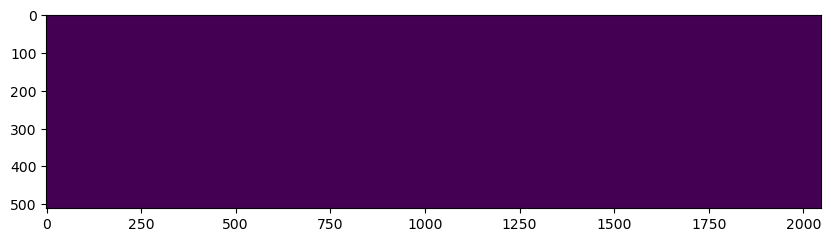

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
plt.imshow(model.flags[1,0].T)

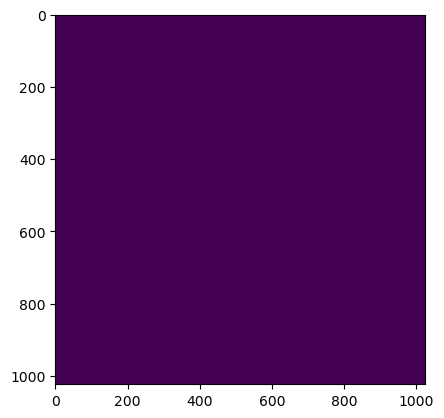

In [13]:
plt.imshow(model.test_masks[2])

In [ ]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

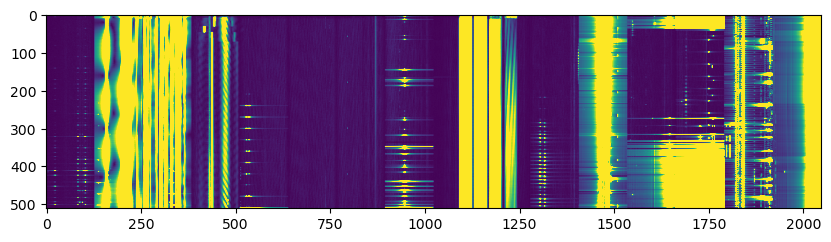

In [9]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
plt.imshow(datarfi_3C129.rfi_antenna_data[0,0].T, vmin=0, vmax=1)